In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [42]:
!ls

allacma_fusca.hard_filtered.sorted.vcf.gz
allacma_fusca.hard_filtered.sorted.vcf.gz.csi
Untitled.ipynb
windowed_diversity.py
windowed_per_sample_diversity.tsv


In [43]:
df = pd.read_csv('windowed_per_sample_diversity.tsv', sep='\t')

In [44]:
df = df[df['chrom'].isin(df['chrom'].unique()[-6:])]
df.dropna(inplace=True)

In [50]:
df['midpoint'] = df['window_start'] + ((df['window_end']-df['window_start'])/2)

In [48]:
samples = df.columns[3:]
df['mean_het'] = df[samples].mean(axis=1)

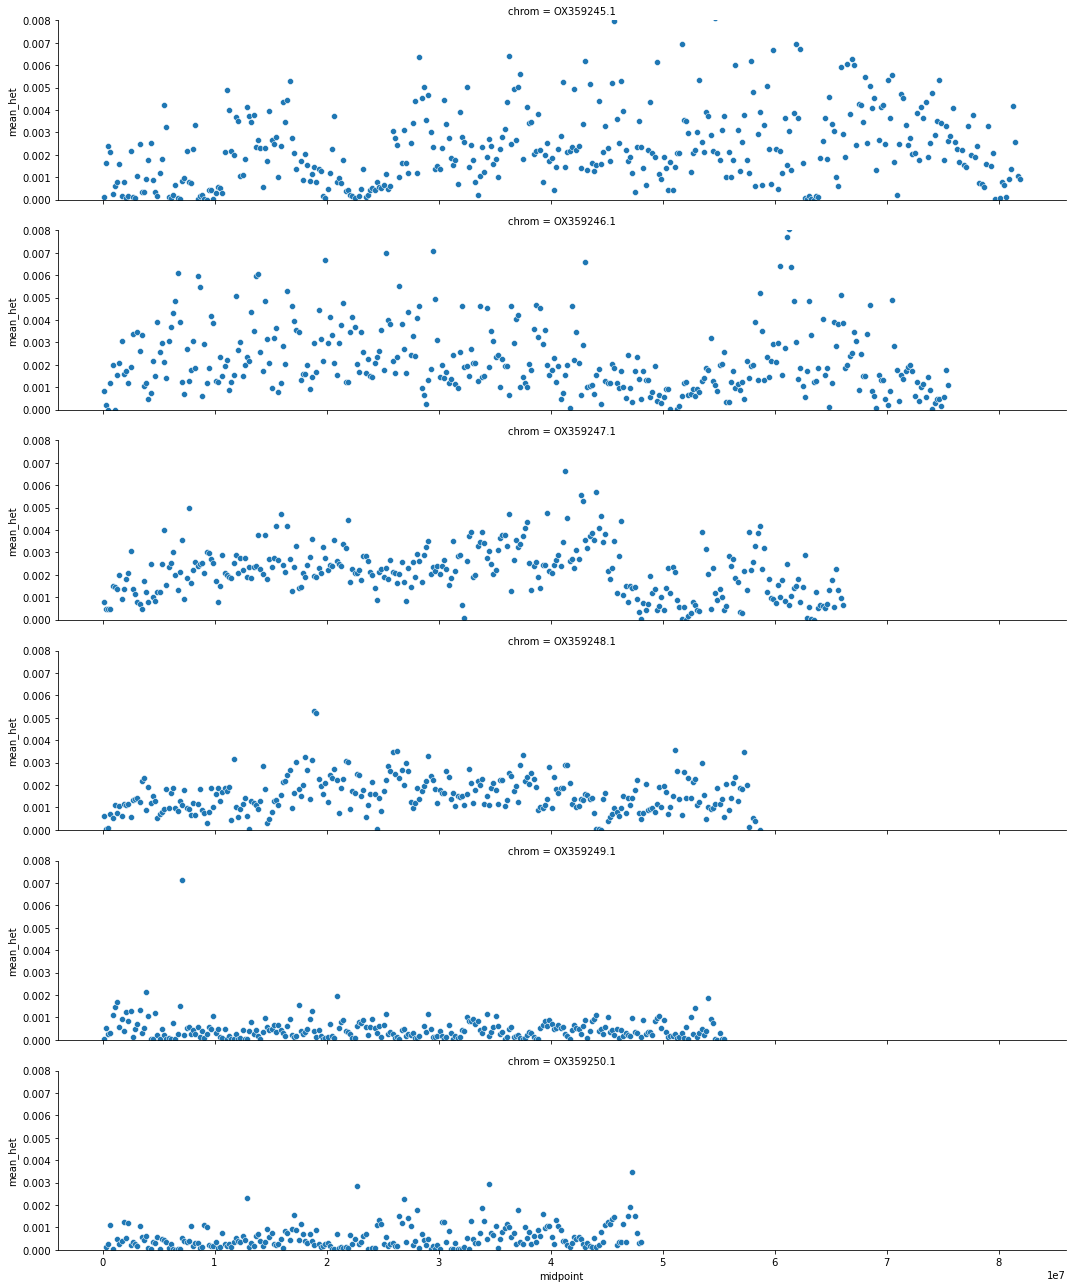

In [60]:
g = sns.FacetGrid(data = df,
             row = 'chrom',
             aspect=5,
             ylim=[0,0.008]
             )

g.map(sns.scatterplot, "midpoint", 'mean_het')

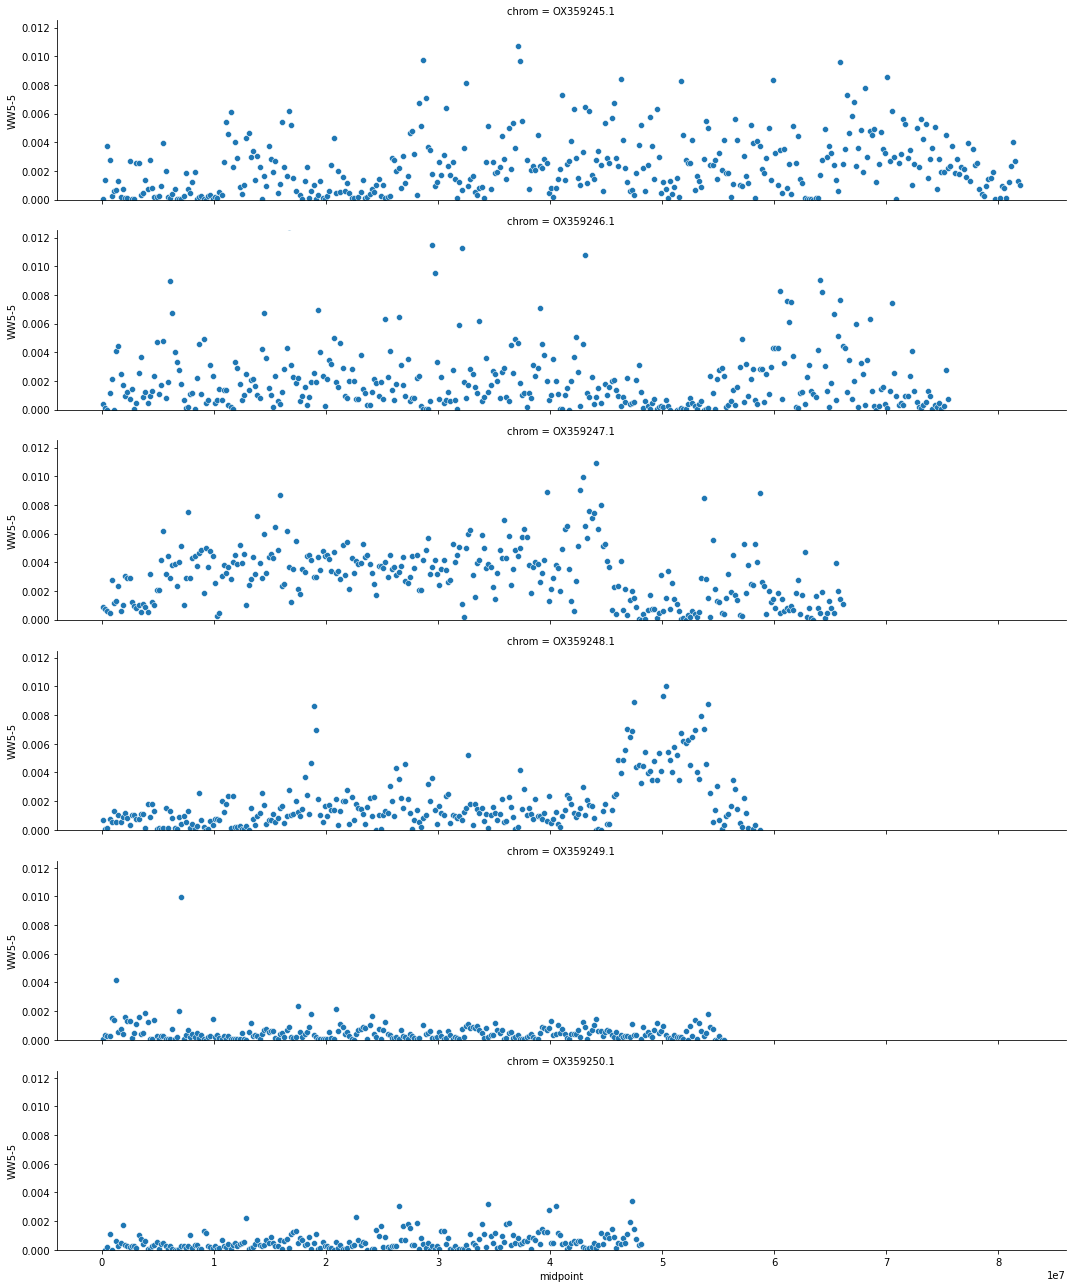

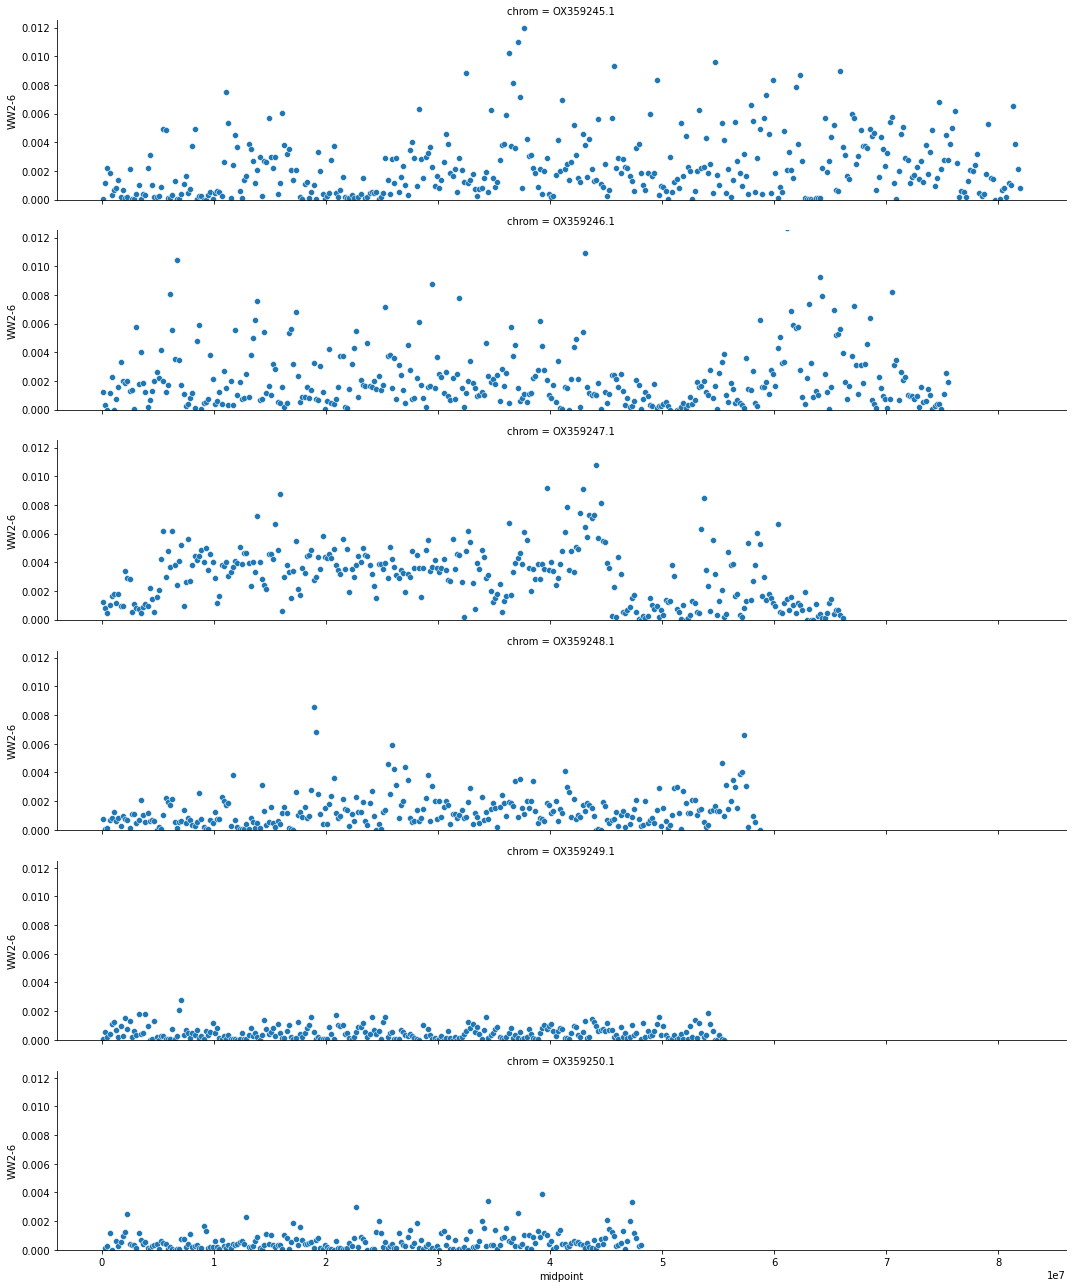

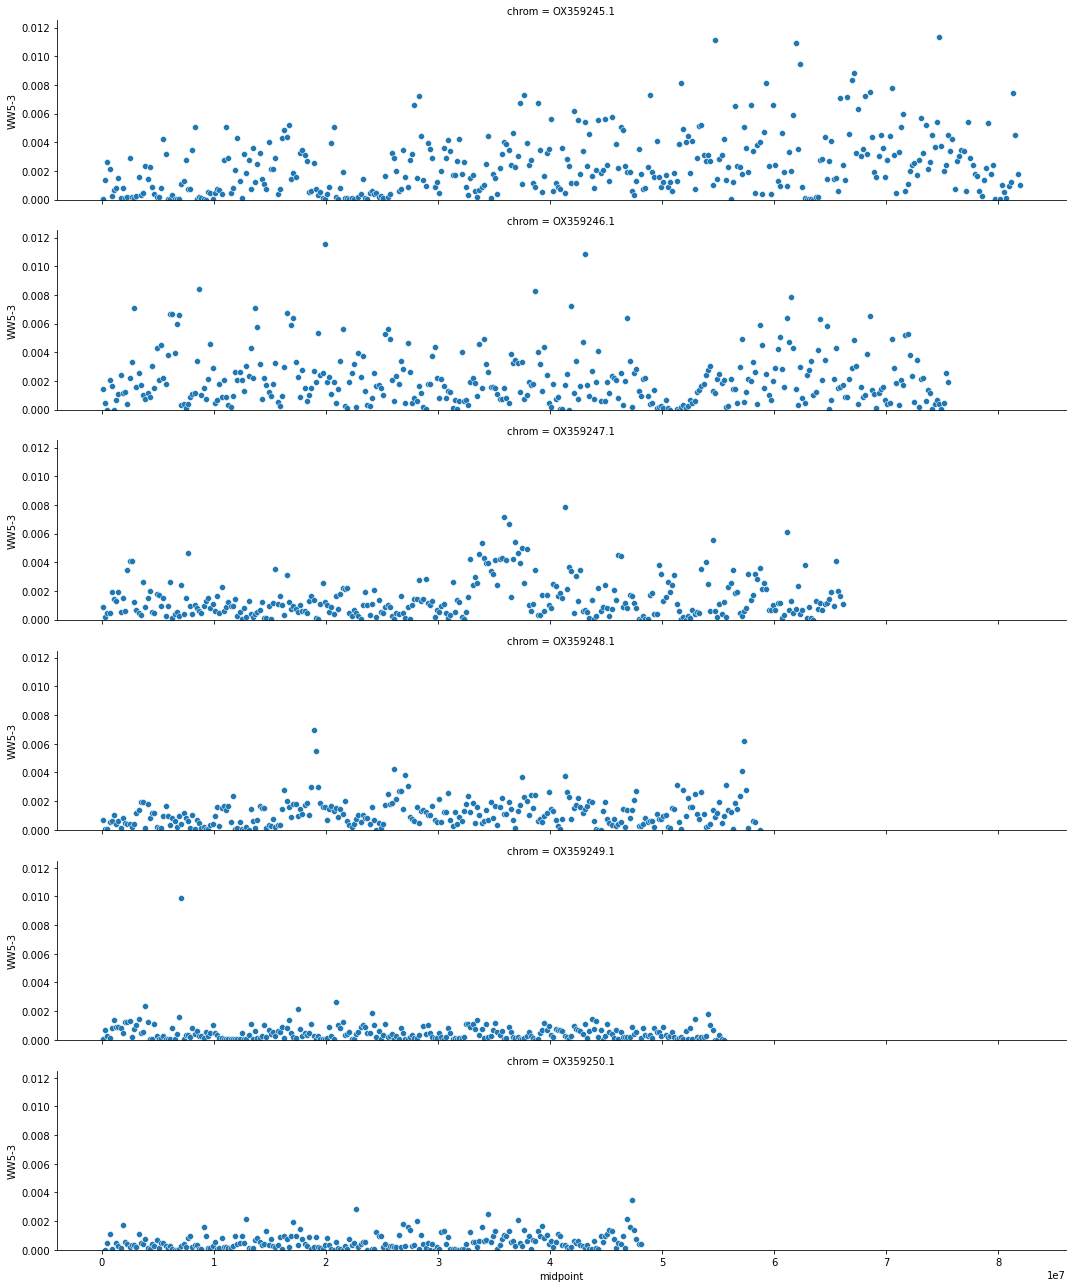

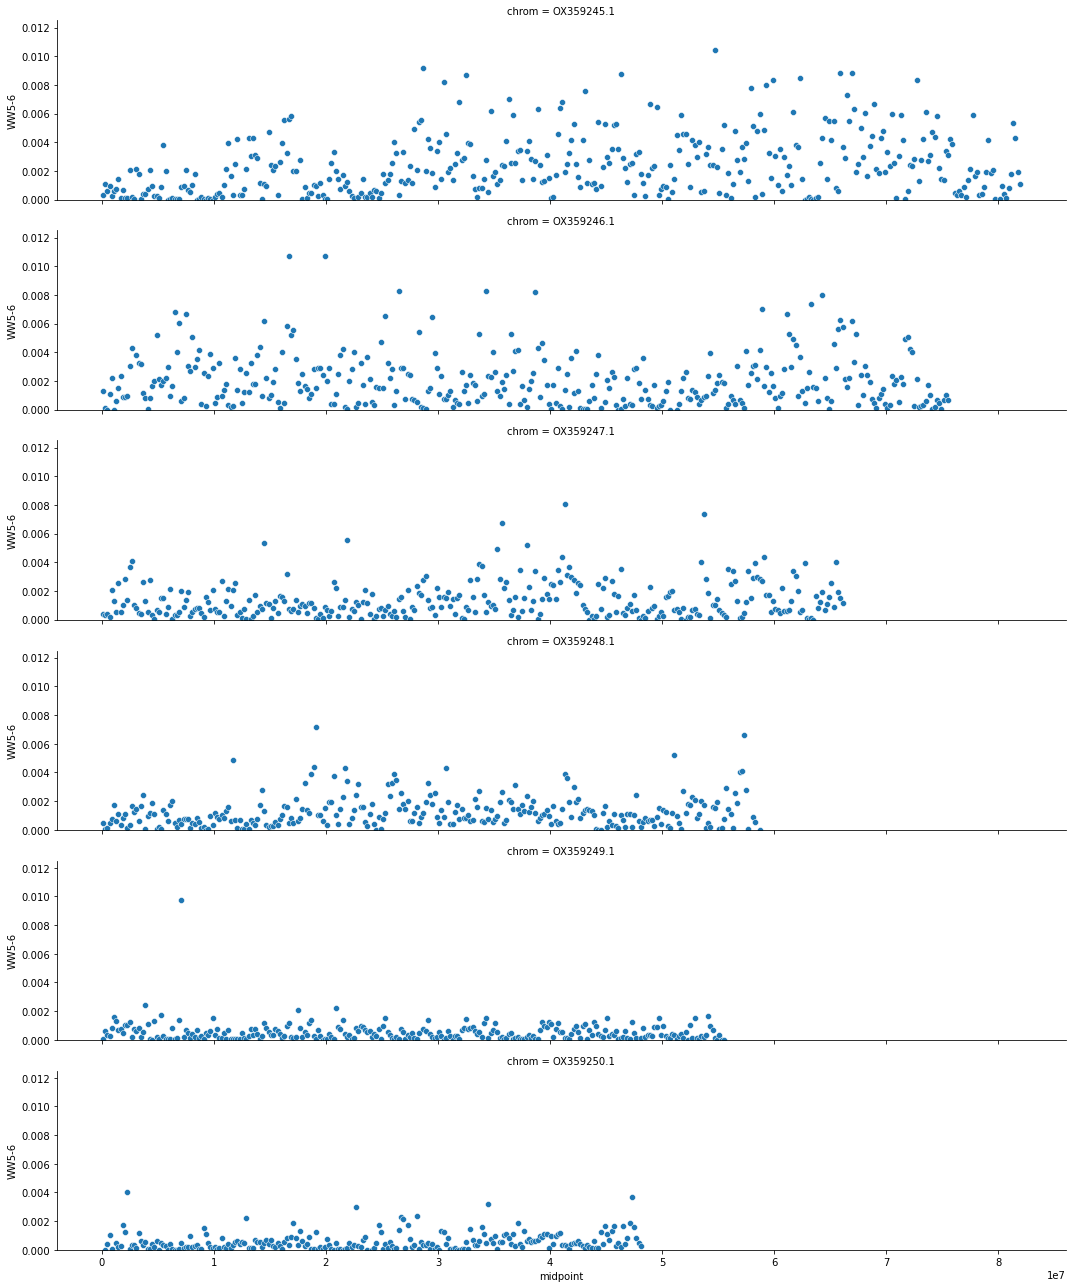

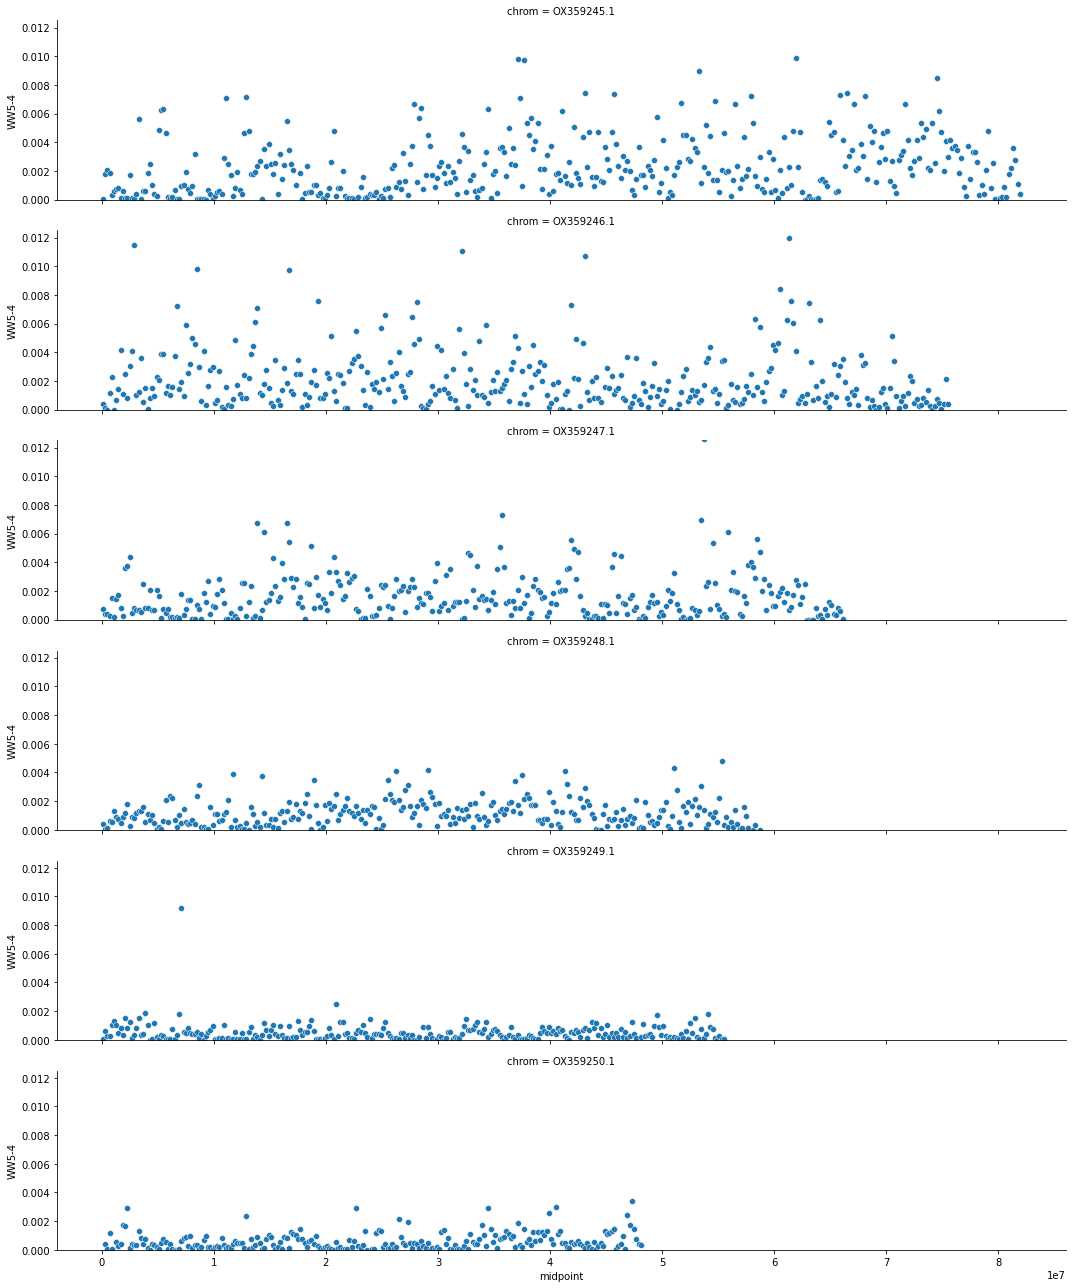

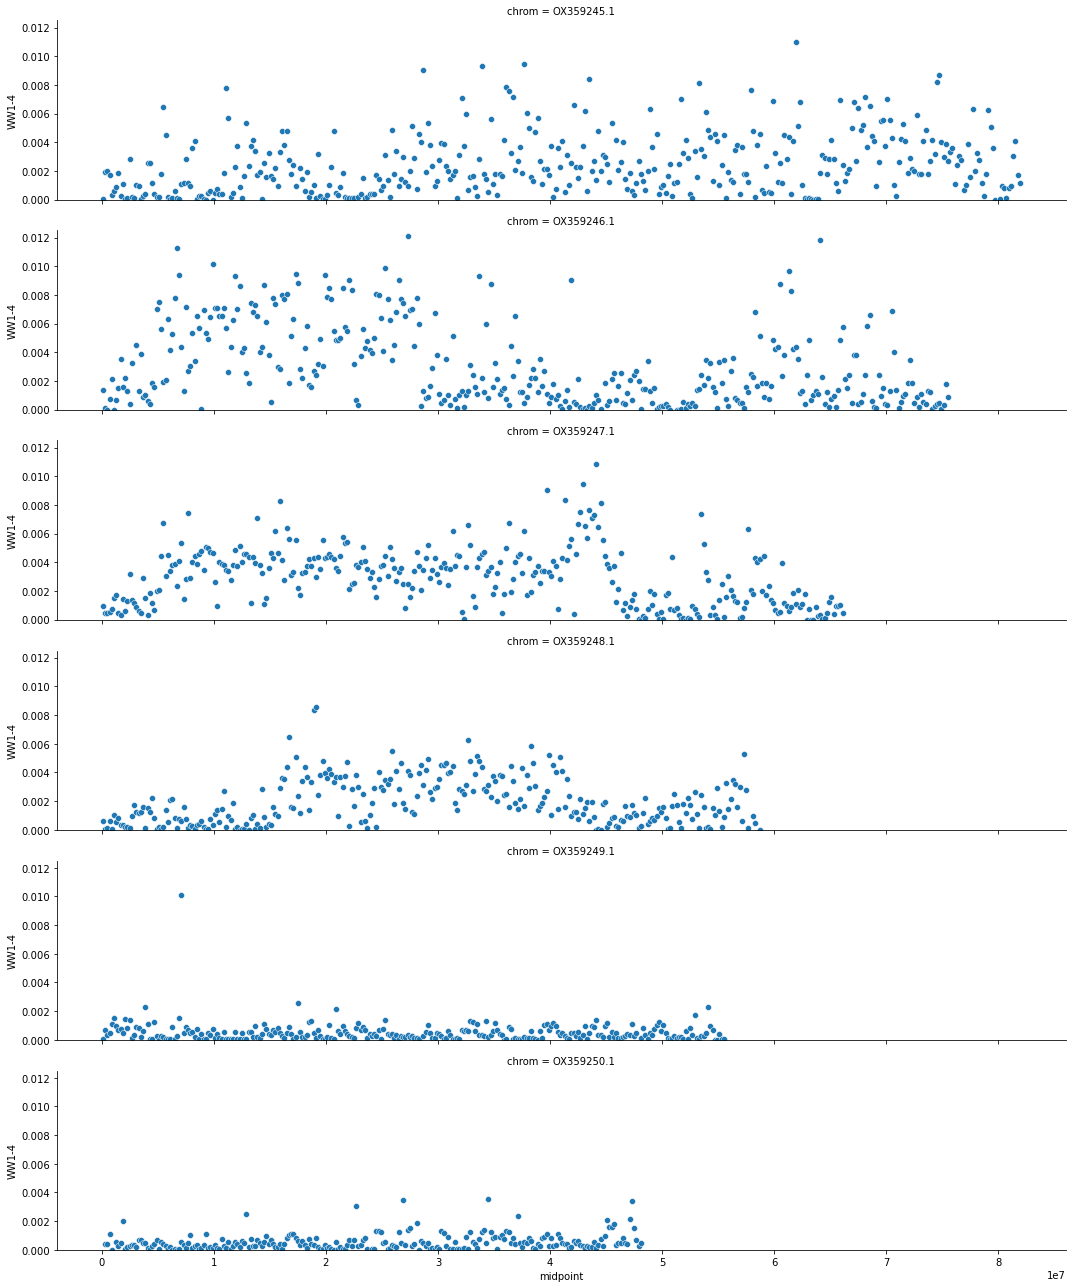

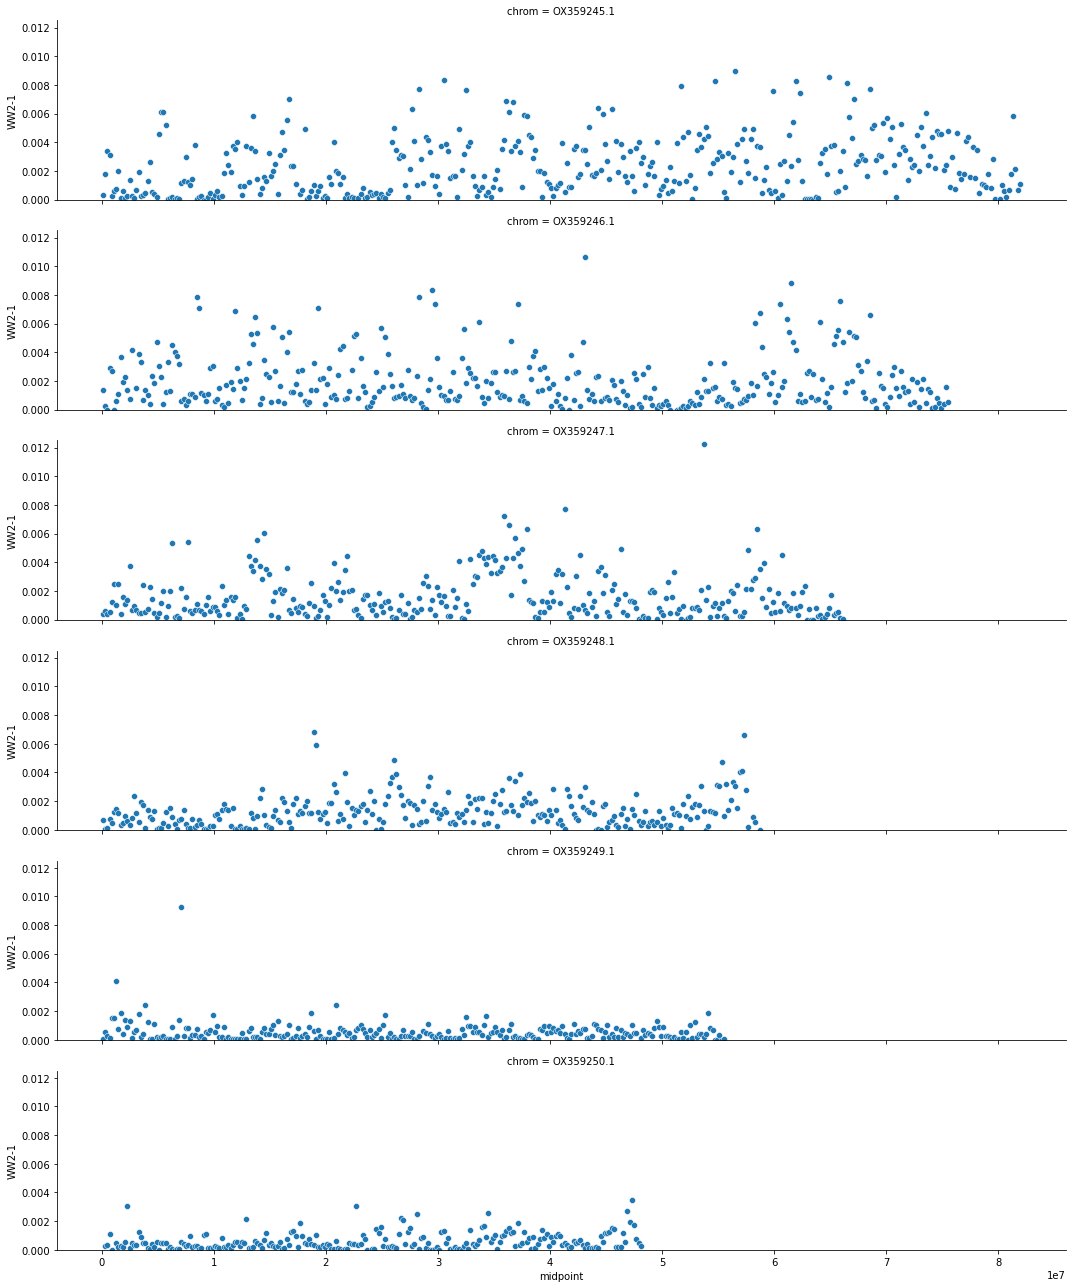

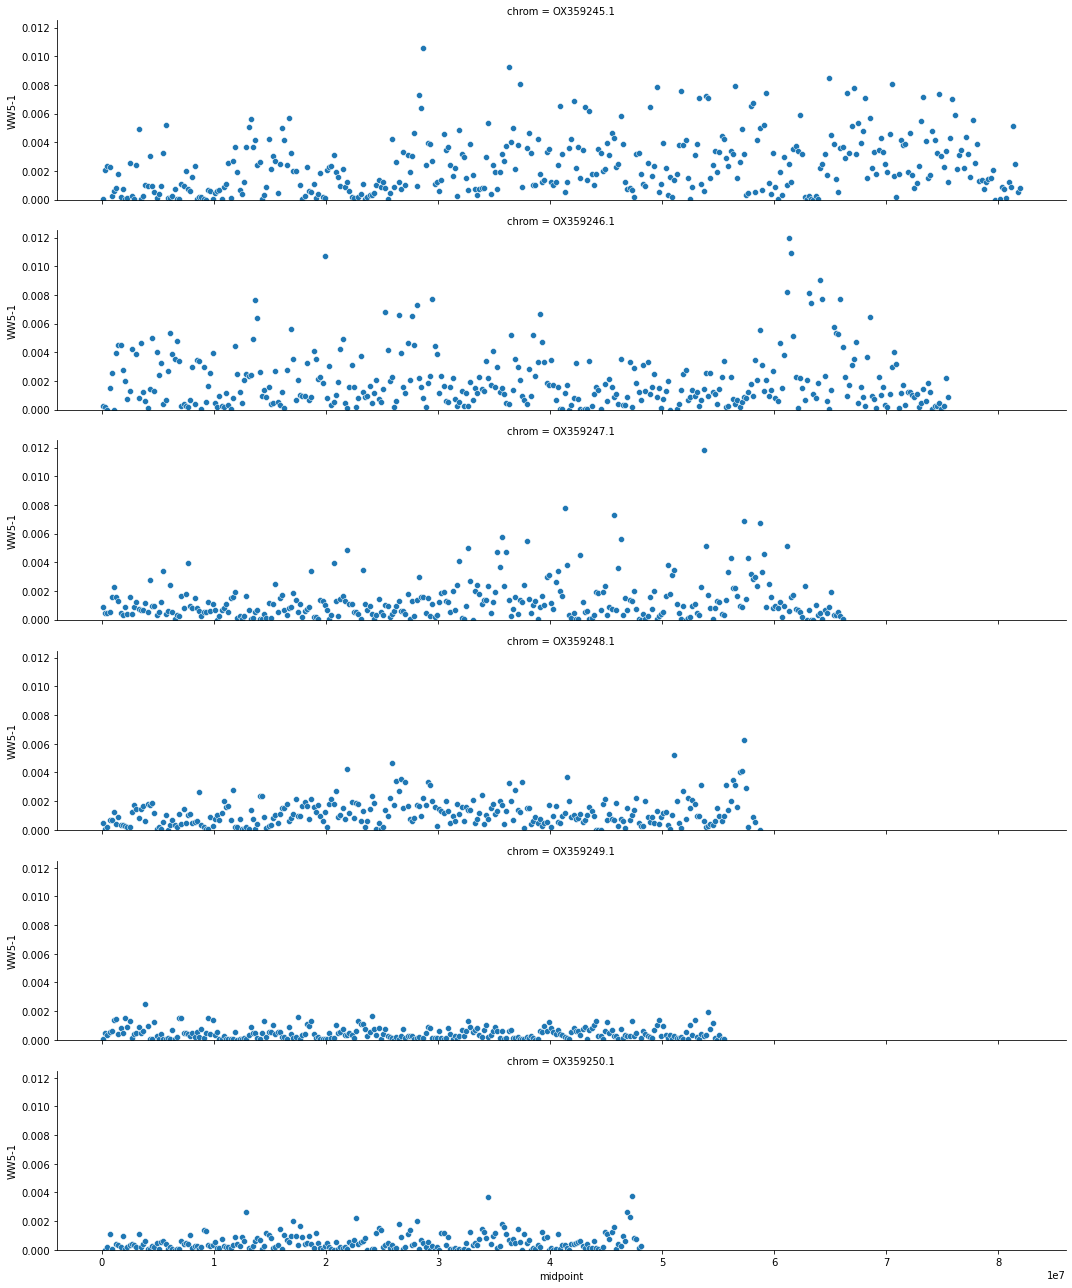

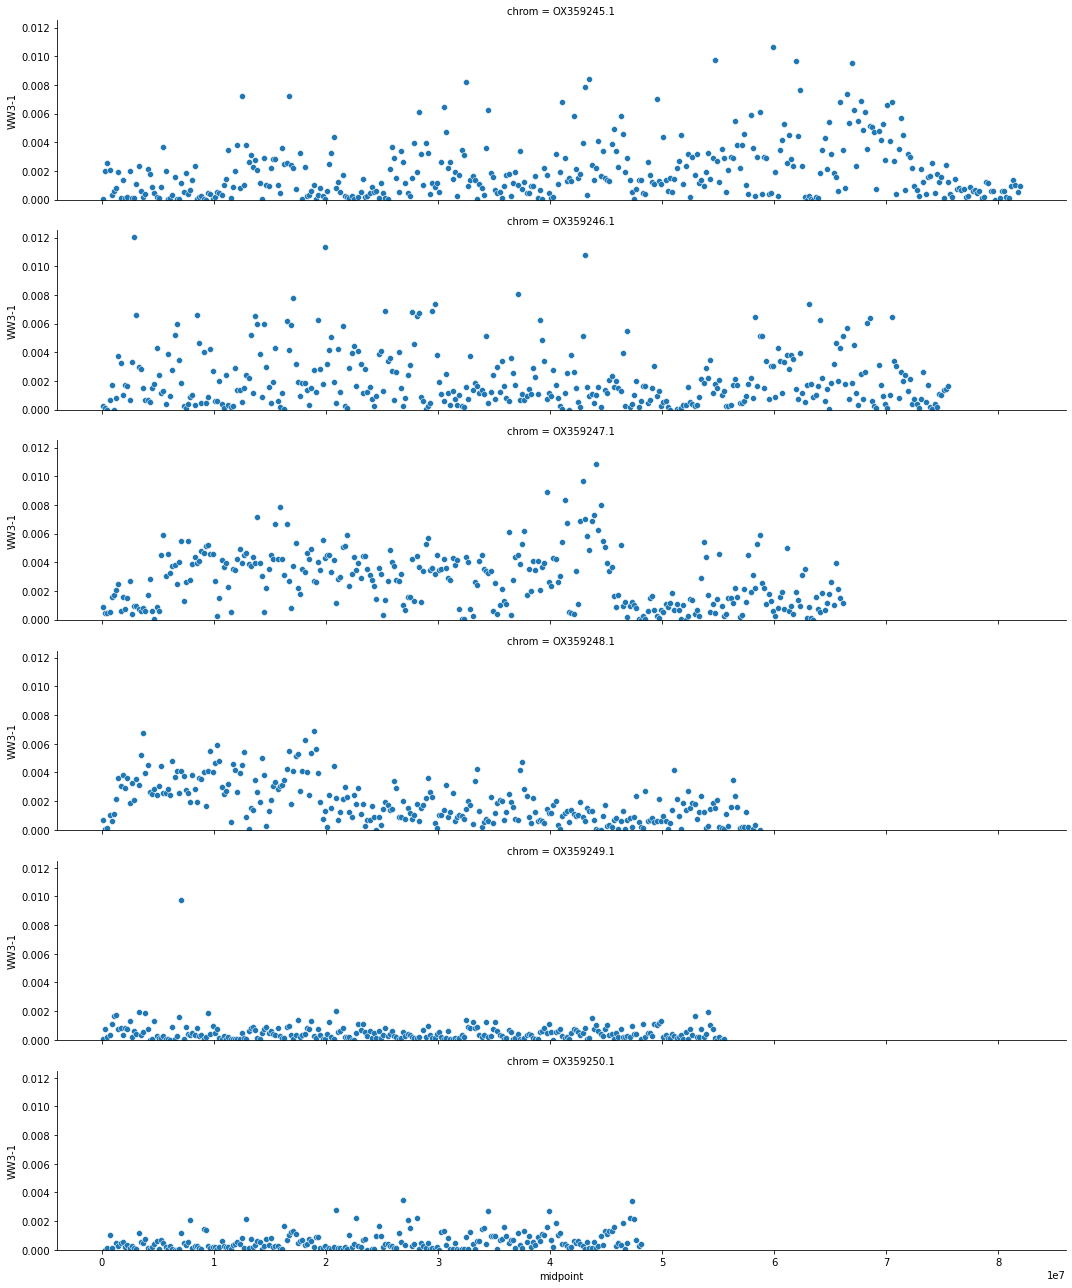

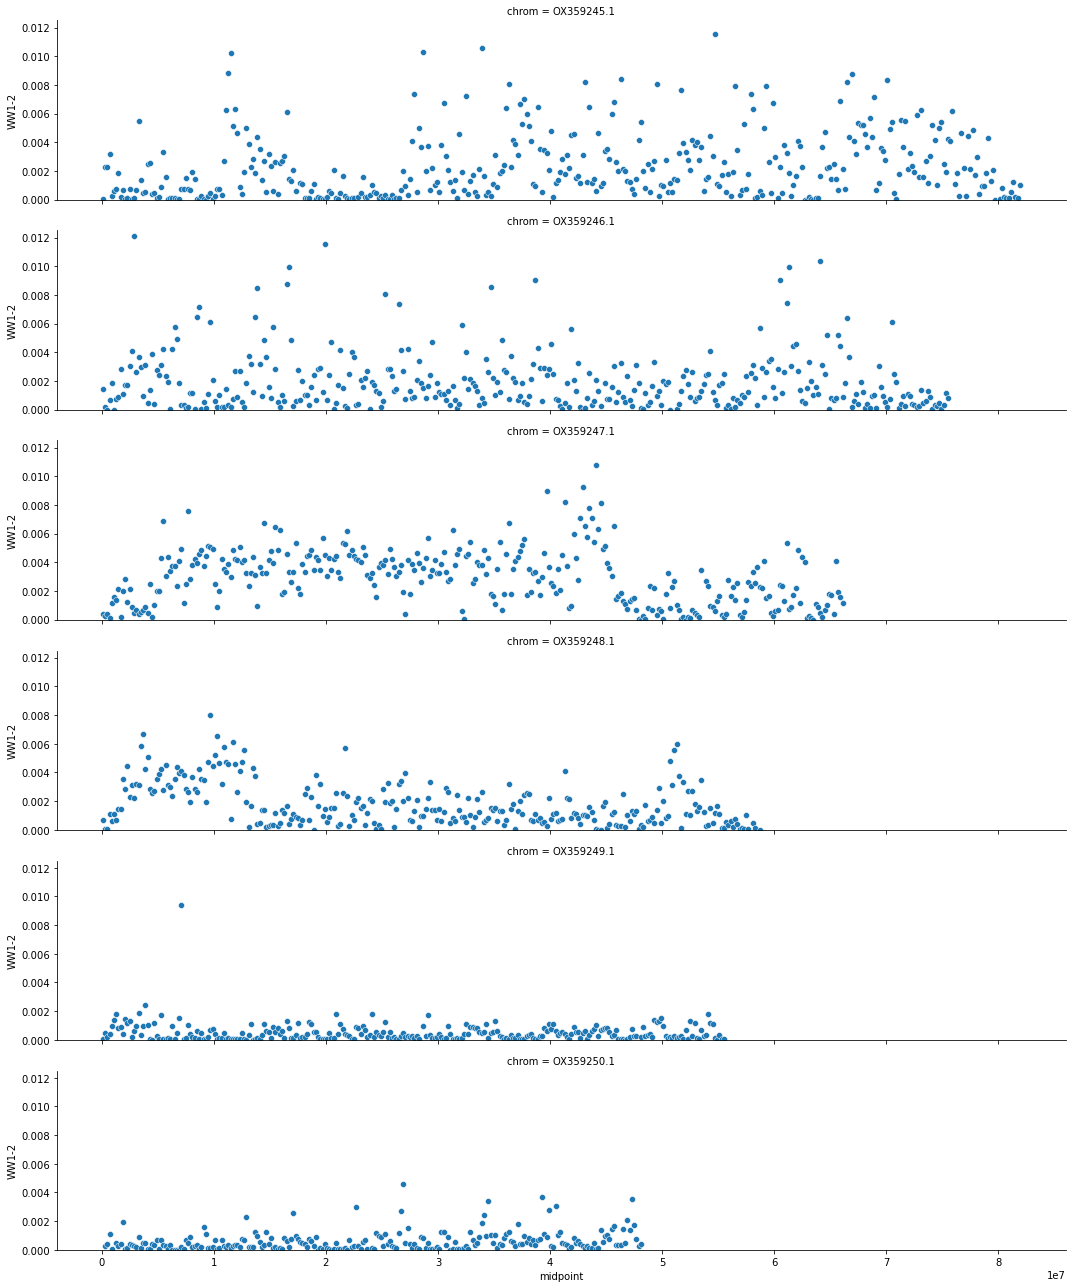

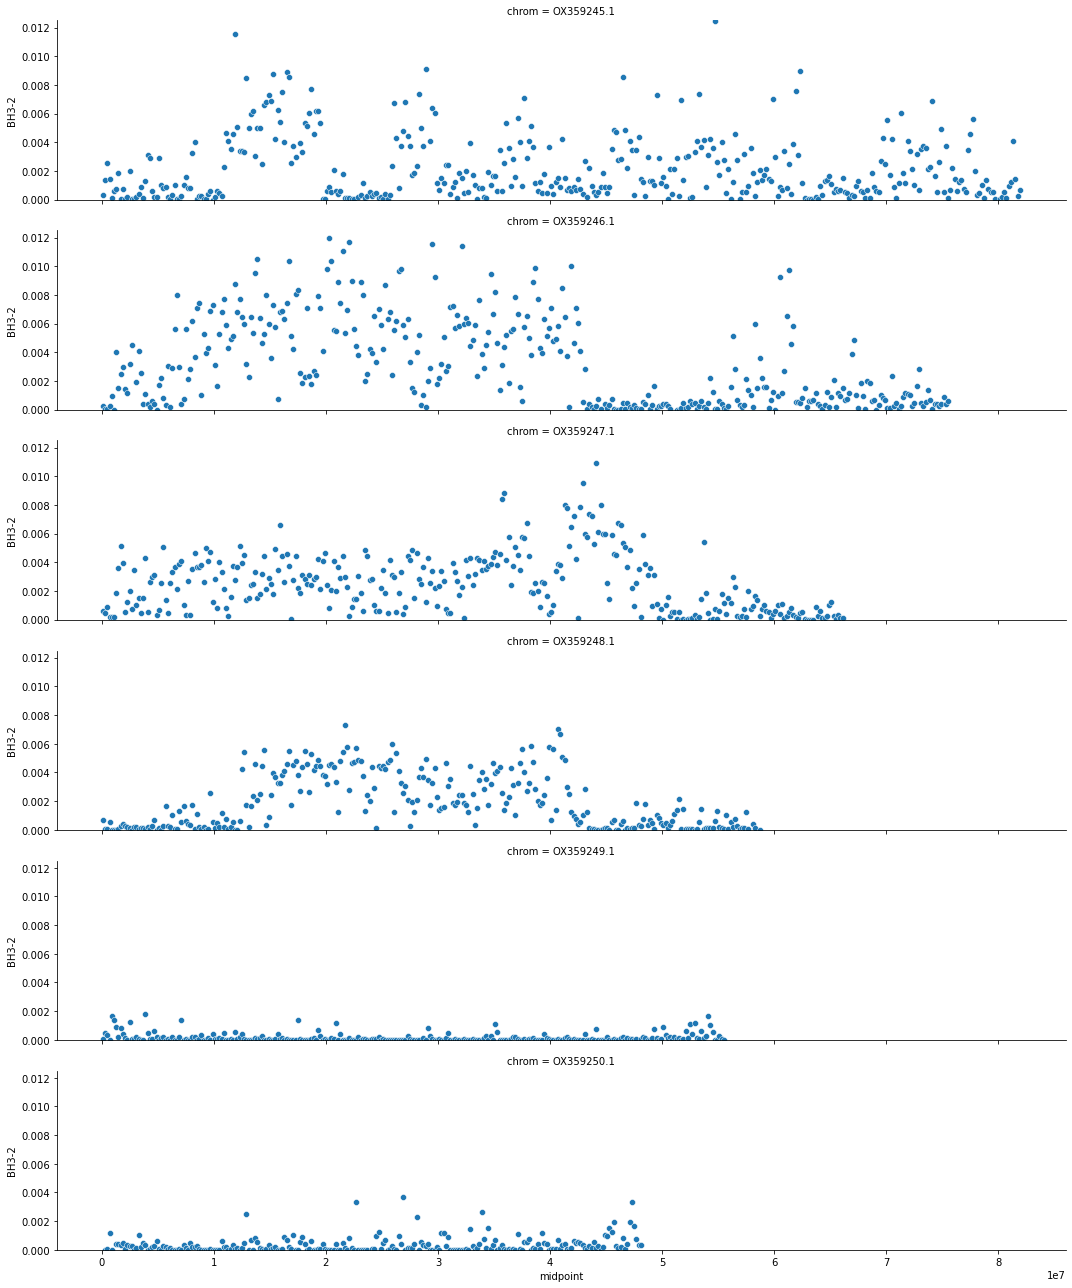

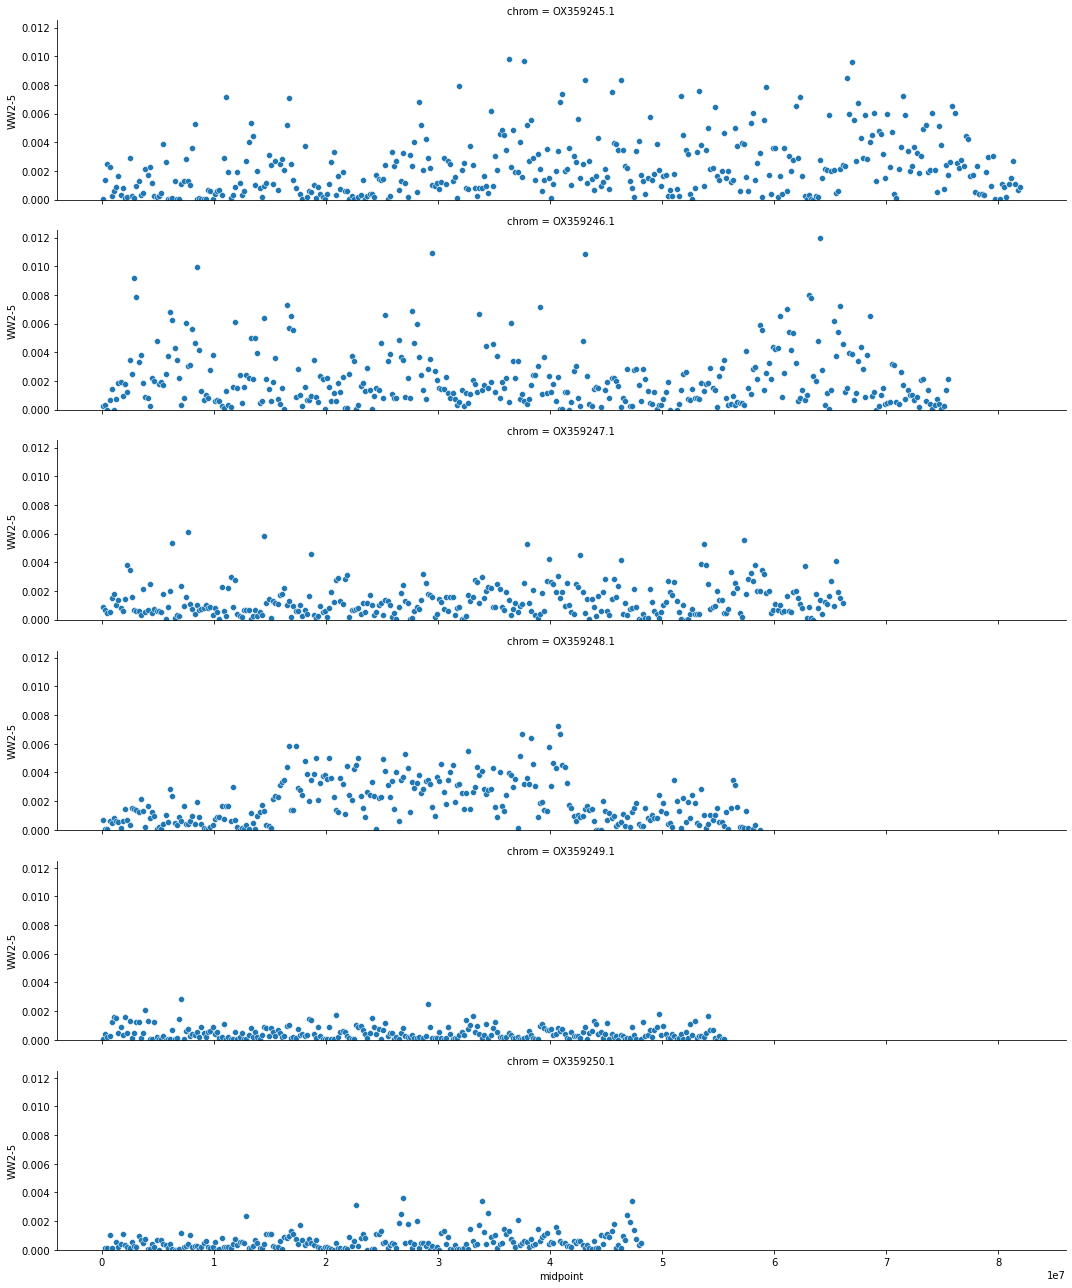

In [52]:
#fig, ax = plt.subplots(figsize=[20, 5], tight_layout=True)

for sample in samples:
    g = sns.FacetGrid(data = df,
             row = 'chrom',
             aspect=5,
             ylim=[0,0.0125]
             )

    g.map(sns.scatterplot, "midpoint", sample)
    plt.savefig(f'{sample}.png')